In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from kelly_utils import kelly, drawdown, har, avg_dd
from tqdm import trange
import statistics as s

In [ ]:
# USER SETTINGS

periods = 252
n_years = 30

burn_in = periods * 30

max_leverage = 10.0
min_leverage = 0.0

f = 1

Rebalancing = 12  # Times per year

scale_long = "none"  # options: "none", "same_avg_vol", "vol_targeting"


sharpe = "variable"  # options: "constant", "variable"

annual_ret = 0.6

expected_return = "known"    # "known" or "unknown"
return_vol_relation = False      # Your 'belief' about the true relation
expected_vol    = "known"      # "known" or "unknown"
estimation_period = 30         # How many years to take average of

deviation = 0.00
rebalance_fraction = 1.0

SR = 0.2  # Expected annualized sharpe ratio.

m = 0.00  # degree of momentum

tc = 0.000

use_momentum = False
return_paths = True

# Parameters for volatility simulations

p_LL = 0.995
p_HH = 0.99
vol_low_annual = 0.12
vol_high_annual = 0.3
rho = 0.95
std_lns = 0.05
jumps_per_year = 0.5
jump_prob = 1 - np.exp(-jumps_per_year*(1/periods))
jump_size = 0.30

c = SR / np.sqrt(periods)

In [44]:
n_sims = 1_000

bust_counter = 0

records = []
for sim in trange(n_sims, desc="Running simlations"):
    res = kelly(n_years, periods, burn_in, p_LL, p_HH, vol_low_annual, vol_high_annual, rho, std_lns, jump_prob, jump_size,
    c, m, annual_ret, sharpe, f, min_leverage, max_leverage, Rebalancing,
    scale_long, use_momentum, return_paths, tc, estimation_period, deviation, rebalance_fraction,
    expected_return, return_vol_relation, expected_vol
    )

    bust_counter += 1 if res['max_dd_kelly'] == -1.00 else 0
    
    # collect every metric from your table
    records.append({
        'sim': sim,
        # Final wealth
        
        'kelly_final_wealth': res['final_wealth_kelly'],
        'bh_final_wealth':    res['final_wealth_long'],
        'vol_final_wealth':   res['final_wealth_volTarget'],
        
        # Drawdown
        
        'kelly_max_dd':     res['max_dd_kelly'],
        'bh_max_dd':        res['max_dd_long'],
        'vol_max_dd':       res['max_dd_volTarget'],
        
        
        # Sharpe
        'kelly_sharpe':     res['sharpe_kelly'],
        'bh_sharpe':        res['sharpe_long'],
        'vol_sharpe':       res['sharpe_volTarget'],

        # Other kelly stats
        'kelly_busts':      bust_counter,
        'kelly weights':    np.mean(res['kelly_weights']),
        'vol_target_weights': np.mean(res['vol_target_weights']),

        # Volatility
        'Mean volatility': res['volatility_path'].mean()
        
        
    })

# build DataFrame of shape (n_sims x 9 metrics)
df_mc = pd.DataFrame.from_records(records).set_index('sim')


styled = df_mc.describe().style

# Optional: format decimals
styled = styled.format("{:.4f}")

styled

Running simlations: 100%|██████████| 1000/1000 [03:55<00:00,  4.25it/s]


,kelly_final_wealth,bh_final_wealth,vol_final_wealth,kelly_max_dd,bh_max_dd,vol_max_dd,kelly_sharpe,bh_sharpe,vol_sharpe,kelly_busts,kelly weights,vol_target_weights,Mean volatility
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,13.5439,5.2689,5.1268,-0.7404,-0.5743,-0.5522,0.2974,0.2835,0.2951,0.0000,1.8171,1.1821,0.1801
std,37.5307,6.9071,6.8717,0.1239,0.1352,0.1300,0.1795,0.1778,0.1803,0.0000,0.0667,0.0204,0.0116
min,0.0412,0.0851,0.1890,-0.9845,-0.9569,-0.9130,-0.1955,-0.2426,-0.2097,0.0000,1.5965,1.1108,0.1504
25%,1.2900,1.4239,1.5975,-0.8343,-0.6677,-0.6429,0.1803,0.1593,0.1778,0.0000,1.7753,1.1689,0.1720
50%,3.6398,3.0569,3.0512,-0.7478,-0.5670,-0.5418,0.2934,0.2872,0.2935,0.0000,1.8186,1.1828,0.1794
75%,11.5073,6.2724,6.0364,-0.6542,-0.4779,-0.4572,0.4223,0.4047,0.4192,0.0000,1.8639,1.1959,0.1875
max,657.2794,54.2245,115.4997,-0.3926,-0.2531,-0.2573,0.8634,0.8343,0.9156,0.0000,1.9934,1.2542,0.2232


In [12]:
results = kelly(
    n_years,
    periods,
    burn_in,
    p_LL,
    p_HH,
    vol_low_annual,
    vol_high_annual,
    rho,
    std_lns,
    jump_prob,
    jump_size,
    c,
    m,
    annual_ret,
    sharpe,
    f,
    min_leverage,
    max_leverage,
    Rebalancing,
    scale_long,
    use_momentum,
    return_paths, 
    tc, 
    estimation_period,
    deviation, 
    rebalance_fraction,
    expected_return, 
    return_vol_relation, 
    expected_vol
)

np.float64(0.0)

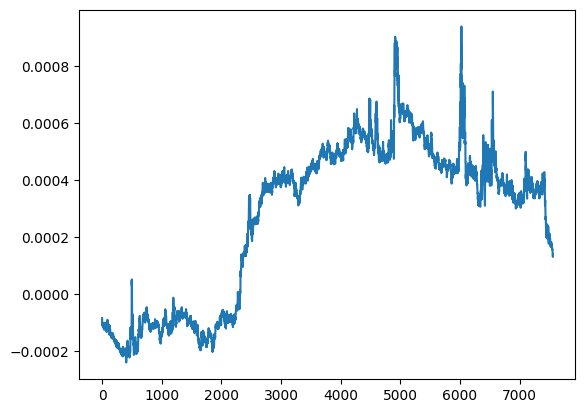

In [53]:
plt.plot(results['returns']['Used expectation'])

In [50]:
table = pd.DataFrame({
    "Buy-and-Hold": {
        "Sharpe ratio": results["sharpe_long"],
        "Final Wealth": results["final_wealth_long"],
        "Max Drawdown": results["max_dd_long"],
    },
    "Kelly": {
        "Sharpe ratio": results["sharpe_kelly"],
        "Final Wealth": results["final_wealth_kelly"],
        "Max Drawdown": results["max_dd_kelly"],
    },
    "Vol Targeting": {
        "Sharpe ratio": results["sharpe_volTarget"],
        "Final Wealth": results["final_wealth_volTarget"],
        "Max Drawdown": results["max_dd_volTarget"],
    }
})

# Round for display
print(table.round(4))

              Buy-and-Hold  Kelly  Vol Targeting
Sharpe ratio        0.5647    NaN         0.5961
Final Wealth       10.1465    1.0         9.8861
Max Drawdown       -0.3414    0.0        -0.2949


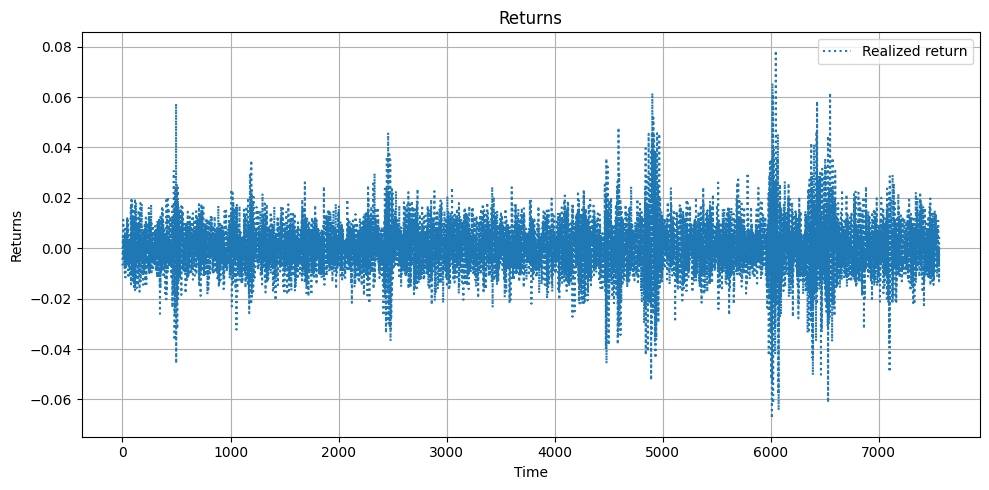

In [51]:
plt.figure(figsize=(10, 5))
#plt.plot(results["returns"]["Actual expectation"], label="Actual expectation", linestyle="--")
#plt.plot(results["returns"]["Used expectation"], label="Used expectation", linestyle="-")
plt.plot(results["returns"]["Realized return"], label="Realized return", linestyle=":")
plt.title("Returns")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.yscale("log")
plt.show()

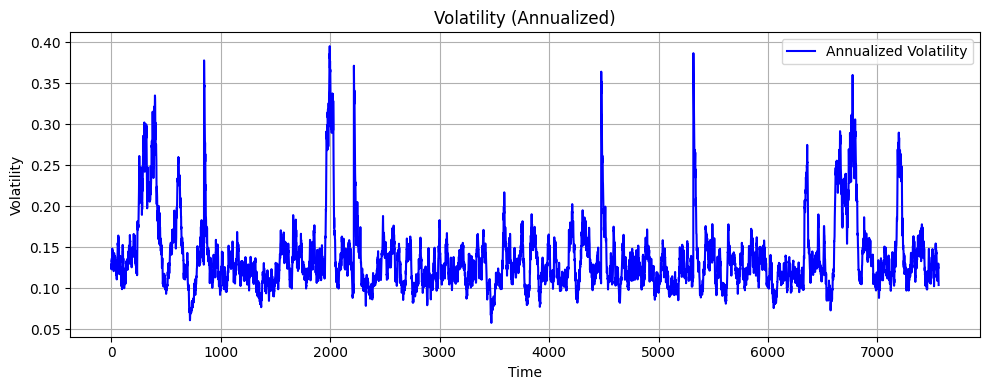

In [36]:
# Plot volatility path (annualized)
plt.figure(figsize=(10, 4))
plt.plot(results["volatility_path"], label="Annualized Volatility", color="blue")
plt.title("Volatility (Annualized)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

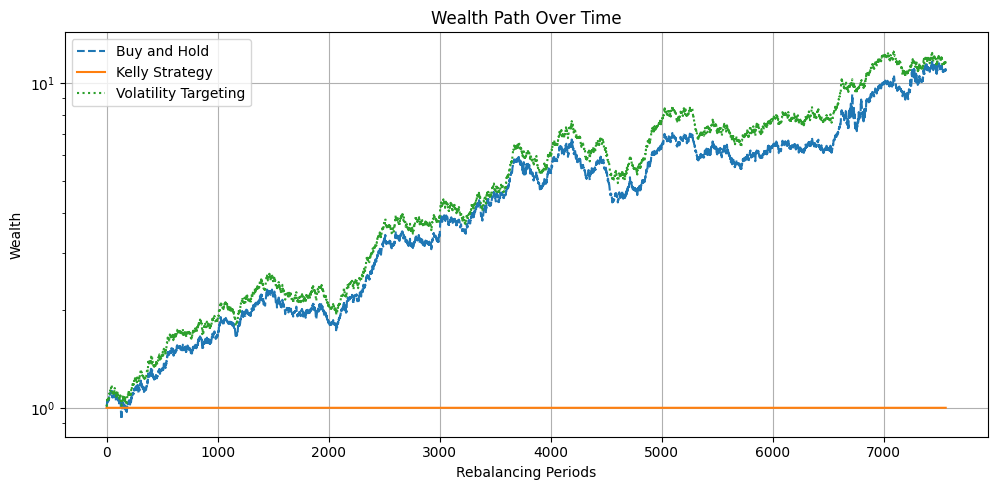

In [18]:
# Plot wealth paths
plt.figure(figsize=(10, 5))
plt.plot(results["wealth_paths"]["buy_and_hold"], label="Buy and Hold", linestyle="--")
plt.plot(results["wealth_paths"]["kelly"], label="Kelly Strategy", linestyle="-")
plt.plot(results["wealth_paths"]["vol_target"], label="Volatility Targeting", linestyle=":")
plt.title("Wealth Path Over Time")
plt.xlabel("Rebalancing Periods")
plt.ylabel("Wealth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale("log")
plt.show()


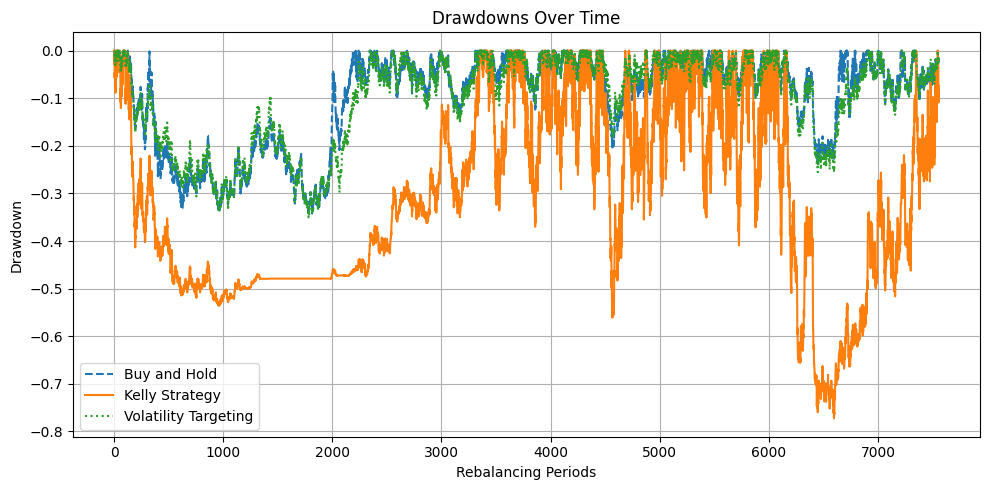

In [38]:
# Compute drawdowns
dd_long = drawdown(results["wealth_paths"]["buy_and_hold"])
dd_kelly = drawdown(results["wealth_paths"]["kelly"])
dd_volT = drawdown(results["wealth_paths"]["vol_target"])

# Plot drawdowns
plt.figure(figsize=(10, 5))
plt.plot(dd_long, label="Buy and Hold", linestyle="--")
plt.plot(dd_kelly, label="Kelly Strategy", linestyle="-")
plt.plot(dd_volT, label="Volatility Targeting", linestyle=":")
plt.title("Drawdowns Over Time")
plt.xlabel("Rebalancing Periods")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
kelly_w = results["kelly_weights"]
volT_w = results["vol_target_weights"]

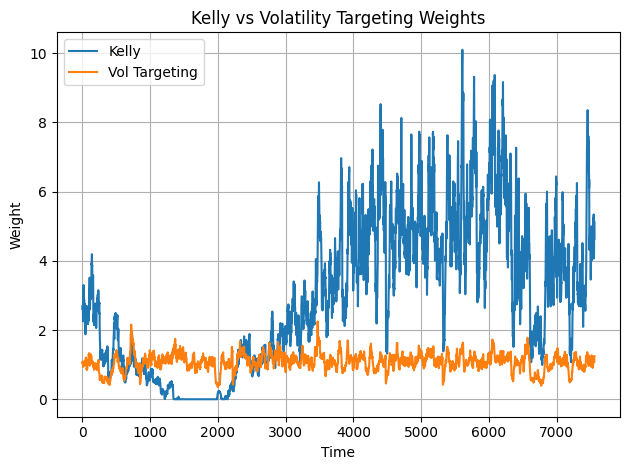

In [40]:
plt.plot(kelly_w, label="Kelly")
plt.plot(volT_w, label="Vol Targeting")
plt.title("Kelly vs Volatility Targeting Weights")
plt.xlabel("Time")
plt.ylabel("Weight")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
n_sims = 1_000

bust_counter = 0

records = []
for sim in trange(n_sims, desc="Running simlations"):
    res = kelly(n_years, periods, burn_in, p_LL, p_HH, vol_low_annual, vol_high_annual, rho, std_lns, jump_prob, jump_size,
    c, m, annual_ret, sharpe, f, min_leverage, max_leverage, Rebalancing,
    scale_long, use_momentum, return_paths, tc, estimation_period, deviation, rebalance_fraction,
    expected_return, return_vol_relation, expected_vol
    )

    bust_counter += 1 if res['max_dd_kelly'] == -1.00 else 0
    
    # collect every metric from your table
    records.append({
        'sim': sim,
        # Final wealth
        
        'kelly_final_wealth': res['final_wealth_kelly'],
        'bh_final_wealth':    res['final_wealth_long'],
        'vol_final_wealth':   res['final_wealth_volTarget'],
        
        # Drawdown
        
        'kelly_max_dd':     res['max_dd_kelly'],
        'bh_max_dd':        res['max_dd_long'],
        'vol_max_dd':       res['max_dd_volTarget'],
        
        
        # Sharpe
        'kelly_sharpe':     res['sharpe_kelly'],
        'bh_sharpe':        res['sharpe_long'],
        'vol_sharpe':       res['sharpe_volTarget'],

        # Other kelly stats
        'kelly_busts':      bust_counter,
        'kelly weights':    np.mean(res['kelly_weights']),
        
        
    })

# build DataFrame of shape (n_sims x 9 metrics)
df_mc = pd.DataFrame.from_records(records).set_index('sim')


styled = df_mc.describe().style

# Optional: format decimals
styled = styled.format("{:.4f}")

styled

Running simlations: 100%|██████████| 1000/1000 [01:59<00:00,  8.37it/s]


,kelly_final_wealth,bh_final_wealth,vol_final_wealth,kelly_max_dd,bh_max_dd,vol_max_dd,kelly_sharpe,bh_sharpe,vol_sharpe,kelly_busts,kelly weights
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,174.0138,6.2310,6.7931,-0.6753,-0.4198,-0.3923,0.3256,0.4089,0.4458,0.9670,1.8312
std,1602.7444,6.7231,6.8222,0.1357,0.1149,0.1052,0.2052,0.1817,0.1827,0.6002,0.6955
min,0.0000,0.3218,0.4085,-1.0000,-0.8357,-0.8005,-0.3893,-0.1845,-0.1383,0.0000,0.0691
25%,1.5660,2.5073,2.8679,-0.7718,-0.4915,-0.4502,0.1908,0.2825,0.3192,1.0000,1.3531
50%,4.3009,4.3961,4.8212,-0.6822,-0.4074,-0.3786,0.3253,0.4088,0.4479,1.0000,1.7896
75%,19.4492,7.7095,8.3898,-0.5781,-0.3358,-0.3175,0.4723,0.5302,0.5657,1.0000,2.2611
max,35965.0144,85.1476,90.3874,-0.1295,-0.1614,-0.1677,0.8995,1.0054,1.0478,2.0000,4.6524


In [ ]:
sharpe = "constant"  # options: "constant", "variable"

n_sims = 1_000

bust_counter = 0

records = []
for sim in trange(n_sims, desc="Running simlations"):
    res = kelly(n_years, periods, burn_in, p_LL, p_HH, vol_low_annual, vol_high_annual, rho, std_lns, jump_prob, jump_size,
    c, m, annual_ret, sharpe, f, min_leverage, max_leverage, Rebalancing,
    scale_long, use_momentum, return_paths, tc, estimation_period, deviation, rebalance_fraction,
    expected_return, return_vol_relation, expected_vol
    )

    bust_counter += 1 if res['max_dd_kelly'] == -1.00 else 0
    
    # collect every metric from your table
    records.append({
        'sim': sim,
        # Final wealth
        
        'kelly_final_wealth': res['final_wealth_kelly'],
        'bh_final_wealth':    res['final_wealth_long'],
        'vol_final_wealth':   res['final_wealth_volTarget'],
        
        # Drawdown
        
        'kelly_max_dd':     res['max_dd_kelly'],
        'bh_max_dd':        res['max_dd_long'],
        'vol_max_dd':       res['max_dd_volTarget'],
        
        
        # Sharpe
        'kelly_sharpe':     res['sharpe_kelly'],
        'bh_sharpe':        res['sharpe_long'],
        'vol_sharpe':       res['sharpe_volTarget'],

        # Other kelly stats
        'kelly_busts':      bust_counter,
        'kelly weights':    np.mean(res['kelly_weights']),
        
        
    })

# build DataFrame of shape (n_sims x 9 metrics)
df_mc = pd.DataFrame.from_records(records).set_index('sim')


styled = df_mc.describe().style

# Optional: format decimals
styled = styled.format("{:.4f}")

styled

In [ ]:
sorted(df_mc['kelly_max_dd'])

[-0.997843934417828,
 -0.9887660593773921,
 -0.9834585998867618,
 -0.9834048684054355,
 -0.9814154394964092,
 -0.980438334210983,
 -0.9793050730512342,
 -0.9786971195845154,
 -0.9759340900274078,
 -0.9737871892413177,
 -0.9726739808675026,
 -0.9718886747756885,
 -0.9715773538662855,
 -0.971028098821087,
 -0.9706382874435381,
 -0.9704830552615521,
 -0.9698753192540389,
 -0.9693165968724512,
 -0.9671260379810185,
 -0.9668094194893232,
 -0.9641008003285568,
 -0.9633228857882271,
 -0.9622443768989446,
 -0.9593595316489366,
 -0.959026636978085,
 -0.9586026696203418,
 -0.9570733706809217,
 -0.9562835142905594,
 -0.955640427388087,
 -0.9538940784327606,
 -0.9535217073396403,
 -0.9518986680125773,
 -0.9480910459775838,
 -0.9478555305407614,
 -0.9478378937363339,
 -0.9474390751493649,
 -0.9465279384193106,
 -0.944053101644814,
 -0.9439281170095186,
 -0.9433041547001954,
 -0.9430189902663705,
 -0.9417326808224389,
 -0.9387965163586254,
 -0.9384450422547531,
 -0.9372473984689069,
 -0.937157260969

In [ ]:

n_sims  = 250
summary = []

for f_test in [0.5,0.75,1.0, 1.25, 1.5, 2.0]:
    records = []
    busts_kelly = 0
    for sim in trange(n_sims, desc = "Running simlations"):
        res = kelly(n_years, periods, burn_in, 
        p_LL, p_HH, vol_low_annual, vol_high_annual, rho, std_lns, jump_prob, jump_size,
        c, m, annual_ret, sharpe, f_test, min_leverage, max_leverage, Rebalancing,
        scale_long, use_momentum, return_paths, tc, estimation_period,  expected_return, expected_vol
    )
        if res['final_wealth_kelly'] < 1e-8:
            busts_kelly += 1
        # extract everything
        records.append({
            # final wealth
            'bh_fw':    res['final_wealth_long'],
            'kelly_fw': res['final_wealth_kelly'],
            'vol_fw':   res['final_wealth_volTarget'],
            # max drawdown
            'bh_max_dd':    res['max_dd_long'],
            'kelly_max_dd': res['max_dd_kelly'],
            'vol_max_dd':   res['max_dd_volTarget'],
            # mean drawdown
            'bh_avg_dd':    avg_dd(res['wealth_paths']['buy_and_hold']),
            'kelly_avg_dd': avg_dd(res['wealth_paths']['kelly']),
            'vol_avg_dd':   avg_dd(res['wealth_paths']['vol_target']),
            # weights & vol path means
            'kelly_w_m':       res['kelly_weights'].mean(),
            'VT_w_m':       res['vol_target_weights'].mean(),
            'vol_path_m': res['volatility_path'].mean(),
        })

    df_mc = pd.DataFrame.from_records(records)

    # compute the median for final wealth variables
    median_fw = df_mc[['bh_fw', 'kelly_fw', 'vol_fw']].median()

    # compute the mean for the rest
    mean_others = df_mc.drop(columns=['bh_fw', 'kelly_fw', 'vol_fw']).mean()

    # combine both median and mean results
    summary.append({'f_test': f_test, 
                    **median_fw.to_dict(), 
                    **mean_others.to_dict(),
                    'Kelly_busts': busts_kelly})

# build summary DataFrame
summary_df = pd.DataFrame(summary).set_index('f_test')

# transpose to get: rows=metrics, cols=f_test
final_table = summary_df

print(final_table)


Running simlations:   0%|          | 0/250 [00:00<?, ?it/s]


NameError: name 'use_TC' is not defined